# Predicting Probability of MLB Batter Swinging Using Machine Learning

---
embed-resources: true
echo: false
---

### Predicting swing probability using a calibrated and tuned random forest classifier model

## Introduction

The goal of this report is to describe the methods and results of a probability model that seeks to estimate the probability that a batter swings at a given pitch. This will be done using pitch characteristics and game situation information for a specific pitcher. This can provide game-time insights into predicted tendencies of batters using every pitch thrown by a pitcher throughout the season.

This will use data from one pitcher, Zac Gallen, but this process is designed so that it can be easily replicated for other pitchers. To accomplish this, a calibrated random forest classifier model will be used along with various preprocessing techniques.

## Methods

In [18]:
# imports

# Data Processing / Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint

# ML Preprocessing
from sklearn.preprocessing import (RobustScaler, OneHotEncoder, StandardScaler)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Modeling, Evaluation
from sklearn.model_selection import (GridSearchCV, KFold)
from sklearn.calibration import CalibratedClassifierCV as CCCV
from sklearn.metrics import (confusion_matrix, brier_score_loss, accuracy_score)
from sklearn.inspection import DecisionBoundaryDisplay
from joblib import dump
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.calibration import calibration_curve


For this report and its associated model, Pandas and NumPy will be used for data handling, Seaborn and Matplotlib will be used for visualization. Various sklearn modules will be used for preprocessing and making the data suitable for machine learning, and also evaluating and visualizing model outcomes. A Random Forest Classifier model will be used to make predictions, which essentially combines many decision tree models, which each use repeated boundary-based decisions to make a prediction, and combines all these tree models' predictions, making a 'forest'.

## Data

This dataset, originally sourced from Statcast (part of Baseball Savant) through the pybaseball package, contains every pitch thrown by Zac Gallen throughout the 2023 season. Data through August 31 will be used to train the model, and data from September 1 to October 2 will be used to test the model. Each row represents a pitch with various characteristics (features).

In [3]:
swing_train = pd.read_parquet(
    "https://lab.cs307.org/swing/data/swing-train.parquet",
)
swing_test = pd.read_parquet(
    "https://lab.cs307.org/swing/data/swing-test.parquet",
)

### Data Dictionary

The data can be considered in different categories: the response variable (what we are trying to predict), fully pitcher controlled variables, mostly pitcher controlled variables, somewhat pitcher controlled variables, downstream pitcher controlled variables, situational information, and fixed batter information. All data types are float64 (decimal number) unless specified otherwise.

**Response**: what we are predicting

* 'swing': integer response variable representing whether the batter swung (1) or took (0)

**Fully Pitcher Controlled**:

* 'pitch_name': object representing name of pitch thrown

**Mostly Pitcher Controlled**: Largely controlled by pitcher but some natural variance (where pitcher's arm is located as ball is thrown)

* 'release_extension': release extension of pitch in feet
* 'release_pos_x': horizontal release position of ball in feet from catcher
* 'release_pos_y': release position of ball in feet from catcher
* 'release_pos_z': vertical release position of ball in feet from catcher


**Somewhat Pitcher Controlled**: Some control from pitchers but a lot of variance, some are dependent on type of pitch thrown

* 'release_speed': release velocity (miles per hour)
* 'release_spin_rate': spin rate (revolutions per minute)
* 'spin_axis': degree of spin axis (0-360)
* 'plate_x': horizontal position of the ball when it crosses home plate (feet)
* 'plate_z': vertical position of the ball when it crosses home plate (feet)

**Downstream Pitcher Controlled**: Somewhat controlled by pitcher but largely functions of previous variables 

* 'pfx_x': horizontal movement from catcher's perspective (feet)
* 'pfx_z': vertical movement from catcher's perspective (feet)

**Situational Information**: variables that are fixed before pitch is thrown but may still have an effect, obvious variables like score and inning omitted for simplicity, all integer data type

* 'balls': number of balls in count
* 'strikes': number of strikes in count
* 'on_3b': 0/1 indicator of runner presence on third base
* 'on_2b': 0/1 indicator of runner presence on second base
* 'on_1b': 0/1 indicator of runner presence on first base
* 'outs_when_up': number of outs pre-pitch

**Fixed Batter Information**: variables about batter, including stance and strike zone

* 'stand': object type representing side of plate batter is standing 'L' or 'R'
* 'sz_top': top of batter's strike zone (feet)
* 'sz_bot': bottom of batter's strike zone (feet)


## Data Exploration

In [4]:
print(f"Samples: {len(swing_train)}, Features: {swing_train.shape[1]-1}")

Samples: 2663, Features: 21


We can observe that in the training dataset, there are 2663 samples each representing a pitch by Zac Gallen in an MLB game up to September 1. Additionally, there are 21 features, meaning that there are 21 variables that we can use to predict our target variable, 'swing'. 

In [5]:
print(f'Overall Swing Probability: {swing_train['swing'].mean()}')
print(swing_train[['swing', 'pitch_name']].groupby('pitch_name').agg("mean").reset_index())

Overall Swing Probability: 0.47728126173488544
        pitch_name     swing
0  4-Seam Fastball  0.470904
1         Changeup  0.536313
2           Cutter  0.451477
3    Knuckle Curve  0.462875
4           Slider  0.496124


Looking at the statistics by pitch type, we can observe that the pitches all have similar but different swing rates, with an overall average of 0.4773. The Changeup has the highest swing rate at 0.5363, and the Cutter has the lowest swing rate at 0.4515. This is a meaningful difference that can assist in predictions.

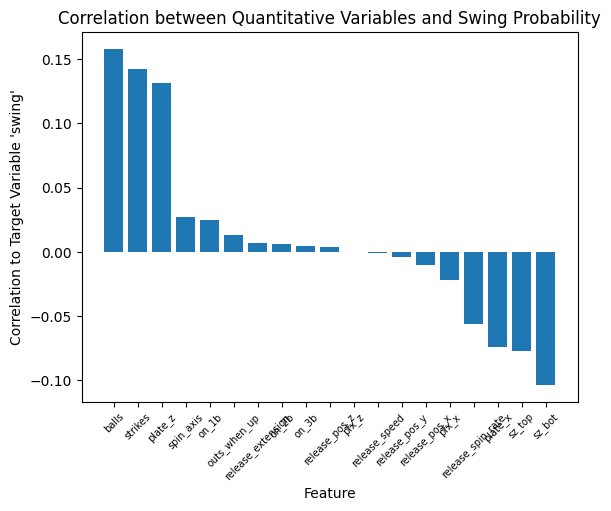

In [36]:
#| fig-cap: "Correlations between Features and Swing"

quant_swing_train = swing_train.drop(columns=['pitch_name', 'stand'])
correlations = quant_swing_train.corr()['swing'].sort_values(ascending=False).iloc[1:]
plt.bar(correlations.index, correlations.values)
plt.xticks(rotation=45, size=7)
plt.title("Correlation between Quantitative Variables and Swing Probability")
plt.xlabel("Feature")
plt.ylabel("Correlation to Target Variable 'swing'")
plt.show()


Here we can see how different variables correlate to swinging probability. Intuitively, higher ball count is correlated to more swinging. Surprisingly, a higher strike count is correlated to more swinging as well. A higher ball position when crossing home plate is also somewhat correlated with a higher swing rate. Conversely, higher spin rates, and strike zone tops and bottoms are negatively correlated with swing rate. 

Overall, all these correlations are low, and an analysis of how these correlations interact with swing rate is necessary to form an effective predictive model.

Correlation between Relative Z Position and Release Speed: 0.5626272706649912
Taken Pitch Relative Z Position: 0.3889511494252873 feet
Swung Pitch Relative Z Position: 0.675177025963808 feet


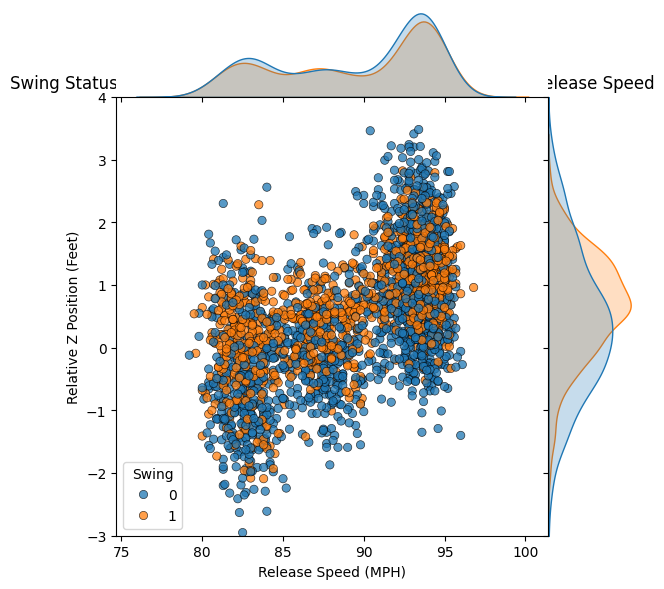

In [7]:
#| fig-cap: "Relationships between Relative Pitch Z Position, Release Speed, and Swing"

viz_swing_df = swing_train[['sz_bot', 'plate_z', 'swing', 'release_speed']]
viz_swing_df['rel_z'] = viz_swing_df['plate_z'] - viz_swing_df['sz_bot']
print(f'Correlation between Relative Z Position and Release Speed: {viz_swing_df['rel_z'].corr(viz_swing_df['release_speed'])}')
taken_train_df = viz_swing_df[viz_swing_df['swing'] == 0]
swung_train_df = viz_swing_df[viz_swing_df['swing'] == 1]
print(f"Taken Pitch Relative Z Position: {taken_train_df['rel_z'].mean()} feet")
print(f"Swung Pitch Relative Z Position: {swung_train_df['rel_z'].mean()} feet")


plot = sns.jointplot(
    data=viz_swing_df,
    x="release_speed",
    y="rel_z",
    hue="swing",
    edgecolor="k",
    alpha=0.75,
    space=0,
)
plot.set_axis_labels(
    xlabel="Release Speed (MPH)",
    ylabel="Relative Z Position (Feet)",
)
plot.ax_joint.legend(
    title="Swing",
    loc="lower left",
)
plt.title("Swing Status by Relative Vertical Pitch Position to Strike Zone, Release Speed")
plt.ylim(-3, 4)
plt.show()

This shows whether the batter swung on each individual pitch given the release speed and relative z position (where the ball came across the plate vertically relative to strike zone). A relative z less than zero indicates a pitch that came in below the bottom of the strike zone. We can observe that taken pitches tend to be lower in the strike zone relative to swung pitches, with averages of 0.39 feet above the strike zone compared to 0.68 feet above the strike zone. We can also observe that pitch speed is moderately correlated (r of 0.56) to relative z position, meaning faster pitches tend to come higher in the strike zone.

Likelihood of Full Count vs. Empty Count Swing: 0.9659574468085104


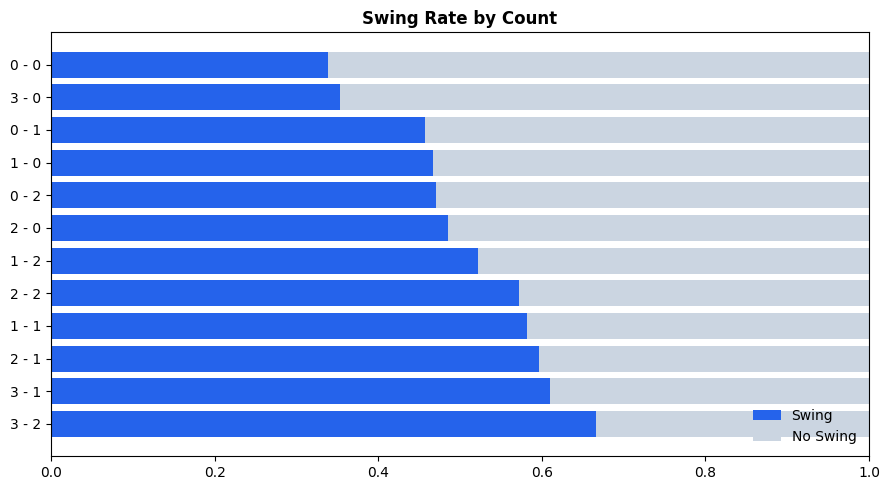

In [12]:
#| fig-cap: "Swing Rate by Pitch Count"

counts = swing_train[["swing", "balls", "strikes"]].groupby(['balls', 'strikes']).agg('mean').reset_index().sort_values(by='swing', ascending=False)
counts['count'] = counts.apply(lambda x: f"{int(x['balls'])} - {int(x['strikes'])}", axis=1)
counts.drop(columns=['balls', 'strikes'], inplace=True)
counts['no_swing'] = 1 - counts['swing']
print(f"Likelihood of Full Count vs. Empty Count Swing: {max(counts['swing']/min(counts['swing'])-1)}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(counts['count'], counts['swing'],    color="#2563EB", label="Swing")
ax.barh(counts['count'], counts['no_swing'], color="#CBD5E1", label="No Swing", left=counts['swing'])
 
ax.set_xlim(0, 1)
ax.set_title("Swing Rate by Count", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

This shows the swing outcome by pitch count. Batters are most likely to hold off when the count is empty or a walk is impending at 3-0. Conversely, batters are most willing to swing when it's a full count. Batters are almost twice (97% more) as likely to swing on full counts than first pitches. 

## Model Tuning & Fitting

In [13]:
X_train = swing_train.drop("swing", axis=1)
y_train = swing_train["swing"]
X_test = swing_test.drop("swing", axis=1)
y_test = swing_test["swing"]

The data is split into what we're trying to predict (target variable) and what we're using to predict it (feature variables). We do this for both the data we're training the model on and the data we're testing our final model on.

In [14]:
qual_cols = ["pitch_name", "stand"]
quant_cols = swing_train.columns.drop(qual_cols)
quant_cols = quant_cols.drop('swing').tolist()

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore"))
    ] 
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_transformer, quant_cols),
        ("categorical", categorical_transformer, qual_cols)    
    ],
    remainder='drop'
)
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", RFC(random_state=7))
    ]
)

This creates a procedure to preprocess the independent variable (feature) data before we put it into the model. There is a different procedure depending on whether the data is categorical (pitch_name, stand) or numerical (balls, strikes, pfx_x, pfx_z and 15 others). These two procedures are combined to make an overall process for cleaning up the data. 

There are a few significant operations being performed on the data. The first one is filling in missing values (imputing). For numerical data, we are just plugging in the median value of the associated variable, but for categorical data, we are plugging in the most frequent. The second operation is scaling. Different variables have different standard deviations, so for numerical variables we scale it, so the mean is 0 and the standard deviation is 1. This ensures that a variable won't have an outsized impact on the model due to the nature of its variance. We also encode the categorical data, assigning 0s and 1s depending on the value, making it numerically processable. 

Finally, we assign what process we want done to what columns, with 'stand' (batting stance) and 'pitch_name' getting the categorical process and everything else getting the numerical process. We then combine this preprocessor with the type of classifier model we want to use (Random Forest Classifier) to create an overall pipeline for our model.

In [15]:
params = {
    "method": ["isotonic", 'sigmoid'],
    "estimator__classifier__n_estimators": [100, 200, 300],
    "estimator__classifier__max_depth": [14, 16, 18],
    "estimator__classifier__criterion": ['log_loss', 'gini'],
    "estimator__classifier__max_features": ['sqrt', 10],
    "estimator__classifier__class_weight": [None, "balanced"],
}

mod = GridSearchCV(CCCV(estimator=pipe),
    param_grid=params,
    scoring='neg_brier_score',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

In [16]:
mod.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CalibratedCla...m_state=7))]))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__classifier__class_weight': [None, 'balanced'], 'estimator__classifier__criterion': ['log_loss', 'gini'], 'estimator__classifier__max_depth': [14, 16, ...], 'estimator__classifier__max_features': ['sqrt', 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_brier_score'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbo

Next, we select a range of parameters we want to test on for our model. This includes what methods we want to calibrate our model's honesty, how many trees are combined to make the forest, how deep these tree models can go, how the model decides what the best decision boundaries in the tree are, the maximum amount of features that can be considered at each split, and the class weight (how the model punishes mistakes for swings vs non swings).

Then, we will try making a model with every possible combination of the metrics we give it, within the range we give it, and have it return the one with the best brier score. Brier score is chosen as the metric because it balances confidence and correctness, pushing the fitted model to be both honest and accurate.

We chose 2 potential methods of calibration, 3 values for how many estimators/trees, 3 values for maximum depth, 2 values for how the model decides what split is best, 2 values for how many features the model can consider at each split, and 2 values for how the model weights class decisions. This results in 2 x 3 x 3 x 2 x 2 x 2 = 144 candidate models. For each given candidate combination, they are evaluated by splitting training data into fifths. A fifth of the inputted train data is held aside for scoring, and the model is trained on the other four fifths, rotating until all five fifths have been used for scoring. The parameter combination resulting in the highest average score across these five validation fits is returned as the model. This is cross-validation. In all, this means that 720 (144 combinations x 5 folds) models will be fitted in pursuit of tuning for the best parameters.

## Results & Model Evaluation

In [22]:
# report model metrics
pprint.pprint(mod.best_params_)
pprint.pprint(-mod.best_score_)

{'estimator__classifier__class_weight': 'balanced',
 'estimator__classifier__criterion': 'log_loss',
 'estimator__classifier__max_depth': 14,
 'estimator__classifier__max_features': 10,
 'estimator__classifier__n_estimators': 100,
 'method': 'sigmoid'}
np.float64(0.1824258826623429)


The best model chose the sigmoid method for calibration, 100 estimators/trees, 10 max features to consider in splits, 14 as the maximum depth for decisions, log loss for evaluating how to split, and a balanced class weight.

The best brier score of this combination (lower is better) is 0.1824.

In [44]:
y_pred_proba = mod.predict_proba(X_test)[:, 1]
test_brier = brier_score_loss(y_test, y_pred_proba)
test_accuracy = accuracy_score(y_test, mod.predict(X_test))
print(f"Test Brier Score: {test_brier}, Test Accuracy: {test_accuracy}")

Test Brier Score: 0.18031954002345088, Test Accuracy: 0.7328767123287672


When tested on unseen data, the model achieved a test brier score of 0.1803 and a test accuracy of 73.28%.

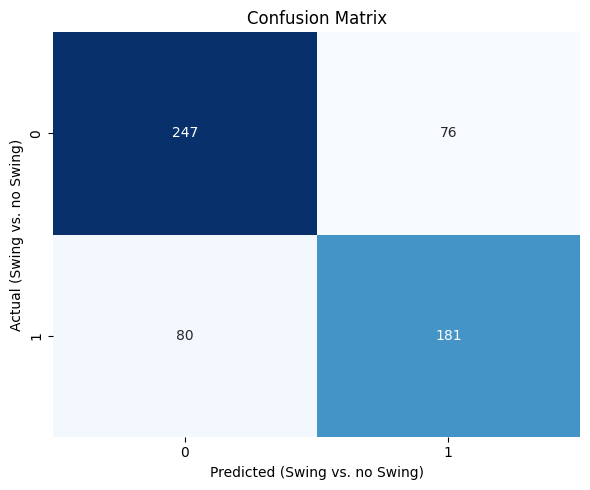

In [35]:
#| fig-cap: "Confusion Matrix for Swing Predictions"

cm = confusion_matrix(y_test, mod.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted (Swing vs. no Swing)")
plt.ylabel("Actual (Swing vs. no Swing)")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

This is a confusion matrix that shows how the model's predictions for individual at-bats stack up against the actual values. In this context, 0 means no swing and 1 means swing. The model predicted 76.5% of takes accurately, and only 69.3% of real swings accurately. 

In [28]:
def plot_reliability_diagram(y_true, y_prob):
    
    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=10,
        pos_label=1,
    )

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(
        prob_pred,
        prob_true,
        "s-",
        label="Learned Classifier",
        color="tab:blue",
    )

    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Perfect Calibration",
        color="tab:orange",
    )

    ax.set_xlabel("Predicted: Average Probability")
    ax.set_ylabel("Actual: Proportion of Positives")

    ax.grid(
        True,
        color="lightgrey",
        linewidth=0.5,
        linestyle=":",
    )

    ax.set_aspect("equal")
    ax.legend()
    plt.show()

In [29]:
def calibration_error(y_true, y_prob, type="expected", n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.searchsorted(bins[1:-1], y_prob)

    bin_sums = np.bincount(bin_idx, weights=y_prob, minlength=len(bins))
    bin_true = np.bincount(bin_idx, weights=y_true, minlength=len(bins))
    bin_total = np.bincount(bin_idx, minlength=len(bins))

    nonzero = bin_total != 0
    prob_true = bin_true[nonzero] / bin_total[nonzero]
    prob_pred = bin_sums[nonzero] / bin_total[nonzero]

    if type == "max":
        calibration_error = np.max(np.abs(prob_pred - prob_true))
    elif type == "expected":
        bin_error = np.abs(prob_pred - prob_true) * bin_total[nonzero]
        calibration_error = np.sum(bin_error) / len(y_true)

    return calibration_error

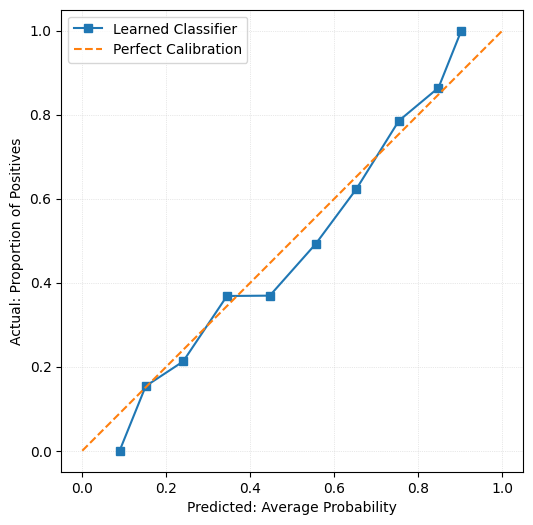

In [30]:
#| fig-cap: "Calibration Error: Predicted Probability vs. Proportion of Positives"
plot_reliability_diagram(y_test, y_pred_proba)

This visualizes how the model's predicted average probability compares to the actual proportion of positives for bins of values. A perfect classifier would be represented with straight diagonal line, since the predicted average probability for each bin would equal the actual proportion of positives. This model came close, with little distance between the model's performance and a perfect model performance.

In [31]:
test_ece = calibration_error(
    y_test,
    y_pred_proba,
    type="expected",
)

max_ece = calibration_error(
    y_test,
    y_pred_proba,
    type="max",
)
print(f"Test ECE: {test_ece:.4f}")
print(f"Max ECE: {max_ece:.4f}")

Test ECE: 0.0319
Max ECE: 0.0976


The model's test ECE was 0.0319, meaning that the model's predicted probabilities are off from actual values by 3.19%. The max ECE was 0.0976. In practice, this is a low expected calibration error, indicating strong calibration.

In [37]:
#| output: false
dump(mod, "swing.joblib", compress=3)

['swing.joblib']

Finally, we will serialize the model by using the dump() function, making the model shareable.

## Discussion & Conclusion

In conclusion, the accuracy may be underwhelming at just over 70% but the model is well calibrated and performs decently given the limitations on the data. With some additional improvements, I would recommend deploying this model.

Although over 20 features on situational, pitcher controlled and batter information are used, the model could benefit from more data. The model is trained exclusively on data from one pitcher which helps, yet there is significant variance in swing tendencies between individual batters that cannot be holistically captured in just stance and strike zone information. For example, certain batters may like to swing at certain pitch types more and batters may be in a slump. Beyond capturable improvements, there are also in-the-moment factors that affect swing probability that may not be able to be captured by data. Overall, batters have different plate disciplines and chase rates, and having this idiosyncratic batter data would further improve the model's accuracy and performance.  

Despite these limitations, the model is still well calibrated. As observed in the graph above, the average predicted probability for each bin is not far off from the true proportion of swings for all values, indicating an effectively calibrated model. The test ECE was 0.0319, and the max ECE was 0.0976. This model can serve as a helpful guide for predicting swing probability, especially when improved upon with batter-specific tendencies and data. I would recommend deploying this model after employing batter-specific information.
